In [1]:
import os
import numpy as np
import pandas as pd

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.negloglik_params import *

from dekef.negloglik_grid_points import *
from dekef.scorematching_penalized_grid_points import *

from dekef.plot_density_1d import *

from IPython.display import Markdown as md

from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
# waiting = waiting[waiting != 108.0]

bw = 5.
kernel_type = 'gaussian_poly2'

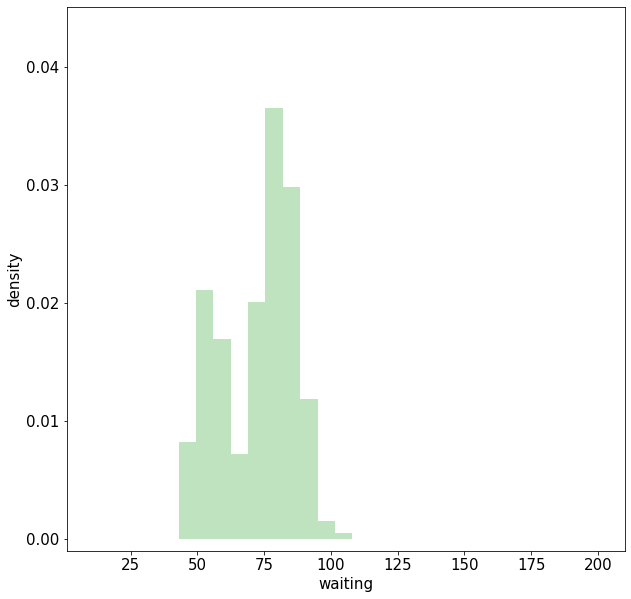

In [3]:
# set plot parameters
font_size = 15
xlimit = (1., 210.)
plot_pts_cnt = 3000
ylimit = (-0.001, 0.0451)

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)

# plt.savefig(f'../plots/histogram.pdf', bbox_inches = 'tight')

In [4]:
108 in waiting

True

In [5]:
base_density = BasedenGamma(waiting, 26., 3.)
base_density.a, base_density.scale

(26.0, 3.0)

In [7]:
seed_no = 1
grid_points = np.arange(1., 181., 1).reshape(-1, 1)
xlimit = (1., 210.)
plot_pts_cnt = 3000

new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)

ml_folder = (f'../data/data=geyser-waiting-PenML-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
             f'grid_points=1-181-1-seed={seed_no}-with108={108 in waiting}')

if not os.path.isdir(ml_folder):
    os.mkdir(ml_folder)

file_name_newdata = f'/new_data.npy'
np.save(ml_folder + file_name_newdata, new_data)

file_name_grid_points = f'/grid_points.npy'
np.save(ml_folder + file_name_grid_points, grid_points)

In [8]:
nll_pen = NegLogLikGridPoints(
    data = waiting, 
    grid_points = grid_points, 
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw
)

In [9]:
# set parameters for computing the density estimate
bmc_params = batch_montecarlo_params(
    mc_batch_size = 5000, 
    mc_tol = 5e-3)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.6, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

ml_log_pen_param_list = [-np.inf, -15., -14., -13., -12., -11., -10., -9.5, -9., -8.5, -8., -7.5, -7., -6.5, -6.]

**************************************************
log penalty = -inf
start time = 18:35:52
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3449786377916959, Relative Error = 0.5602540032246028
Iter = 3, GradNorm = 0.1891181544761336, Relative Error = 0.3071326497372271
Iter = 4, GradNorm = 0.12623521981982141, Relative Error = 0.20500917884282713
Iter = 5, GradNorm = 0.11489116146000936, Relative Error = 0.18658614213080954
Iter = 6, GradNorm = 0.08137596441456478, Relative Error = 0.13215661735278664
Iter = 7, GradNorm = 0.08478729410162356, Relative Error = 0.13769670274974863
Iter = 8, GradNorm = 0.10002994785566514, Relative Error = 0.16245115664907897
Iter = 9, GradNorm = 0.06500098092189426, Relative Error = 0.10556323141668425
Iter = 10, GradNorm = 0.06280896347428867, Relative Error = 0.10200333983029349
Iter = 11, GradNorm = 0.05260888690189979, Relative Error = 0.08543815837598863
Iter = 12, GradNorm = 0.08832857008959194, Relative Error 

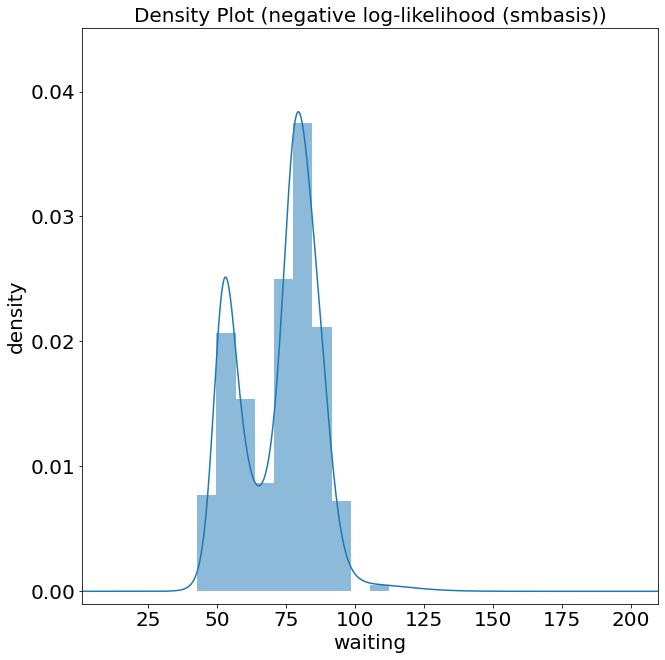

3.024562461654947
**************************************************
log penalty = -15.0
start time = 18:39:28
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.34497767495545645, Relative Error = 0.5602524395542808
Iter = 3, GradNorm = 0.18911703069996538, Relative Error = 0.3071308246964043
Iter = 4, GradNorm = 0.12623424137496517, Relative Error = 0.20500758982371814
Iter = 5, GradNorm = 0.11489019712215866, Relative Error = 0.18658457602183315
Iter = 6, GradNorm = 0.08137504466474087, Relative Error = 0.1321551236558896
Iter = 7, GradNorm = 0.08478657685901464, Relative Error = 0.1376955379296731
Iter = 8, GradNorm = 0.10002912329757725, Relative Error = 0.1624498175459606
Iter = 9, GradNorm = 0.06500017239997273, Relative Error = 0.10556191835670427
Iter = 10, GradNorm = 0.06280824784248716, Relative Error = 0.10200217762620978
Iter = 11, GradNorm = 0.052607940078985393, Relative Error = 0.08543662071171024
Iter = 12, GradNorm = 0.088327782166121

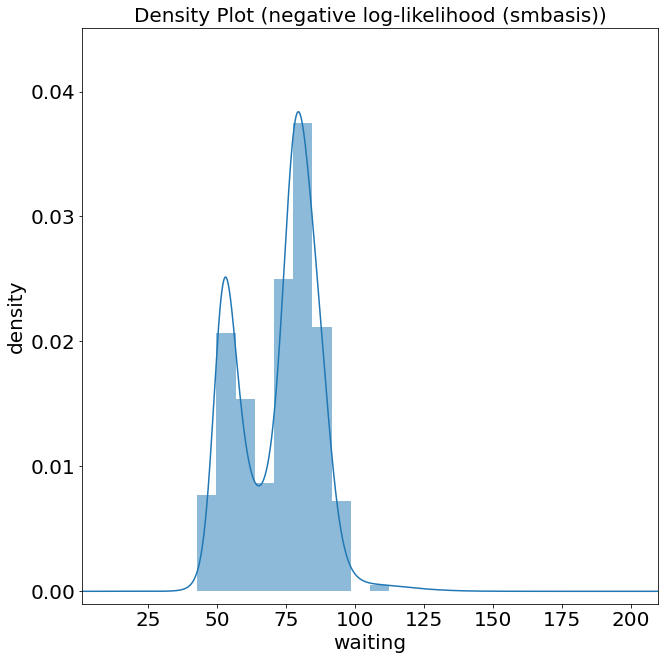

3.0245364725047716
**************************************************
log penalty = -14.0
start time = 18:43:12
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3449760205323363, Relative Error = 0.5602497527294327
Iter = 3, GradNorm = 0.1891150997460979, Relative Error = 0.3071276887786523
Iter = 4, GradNorm = 0.1262325601488644, Relative Error = 0.20500485947015387
Iter = 5, GradNorm = 0.11488854014304316, Relative Error = 0.18658188504598414
Iter = 6, GradNorm = 0.0813734643096875, Relative Error = 0.1321525571194489
Iter = 7, GradNorm = 0.08478534447580051, Relative Error = 0.13769353650827018
Iter = 8, GradNorm = 0.10002770652310984, Relative Error = 0.16244751666851465
Iter = 9, GradNorm = 0.06499878320182602, Relative Error = 0.10555966226389821
Iter = 10, GradNorm = 0.06280701825912981, Relative Error = 0.10200018075184485
Iter = 11, GradNorm = 0.05260631325364725, Relative Error = 0.08543397870635572
Iter = 12, GradNorm = 0.08832642836054128

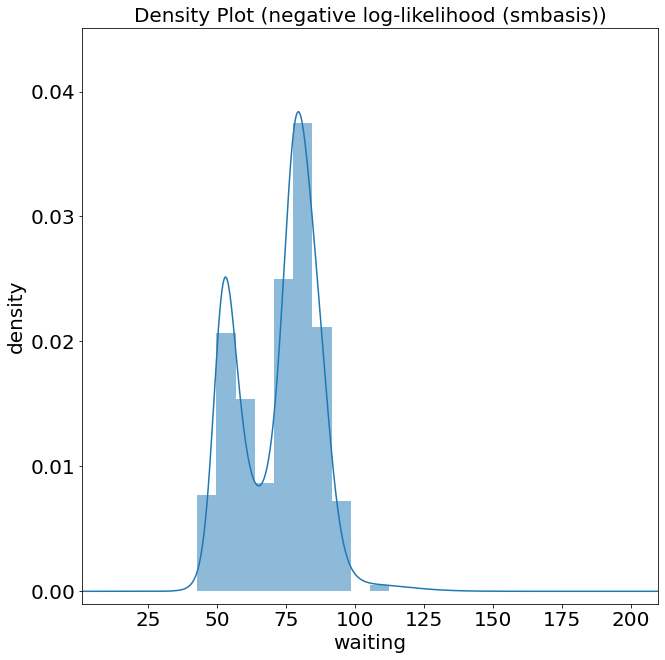

3.0244918172855306
**************************************************
log penalty = -13.0
start time = 18:46:52
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3449715233497438, Relative Error = 0.5602424491915476
Iter = 3, GradNorm = 0.18910985093510713, Relative Error = 0.30711916457730304
Iter = 4, GradNorm = 0.12622799021696893, Relative Error = 0.204997437785567
Iter = 5, GradNorm = 0.11488403616711929, Relative Error = 0.18657457047555762
Iter = 6, GradNorm = 0.08136916867875929, Relative Error = 0.1321455809065468
Iter = 7, GradNorm = 0.08478199477748949, Relative Error = 0.13768809651378136
Iter = 8, GradNorm = 0.10002385564202398, Relative Error = 0.1624412627405668
Iter = 9, GradNorm = 0.06499500741937875, Relative Error = 0.10555353029803236
Iter = 10, GradNorm = 0.06280367637627342, Relative Error = 0.10199475344985136
Iter = 11, GradNorm = 0.05260189161587526, Relative Error = 0.08542679785516323
Iter = 12, GradNorm = 0.0883227487762263

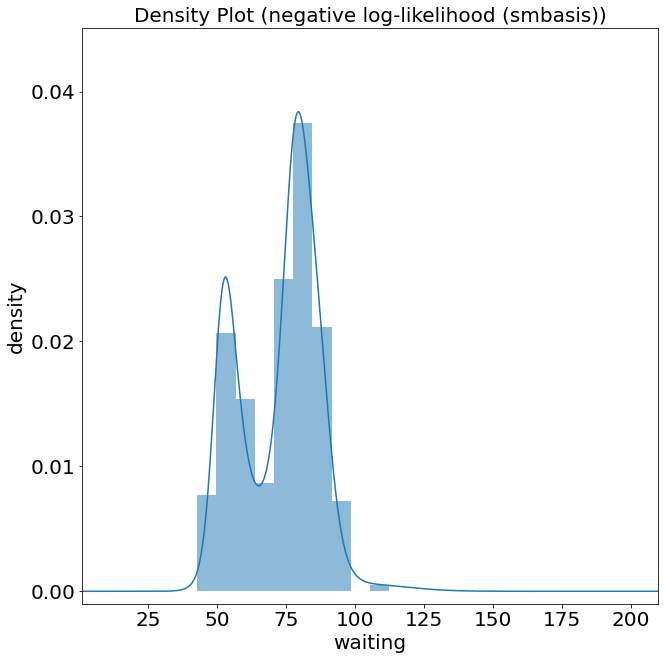

3.024370441175323
**************************************************
log penalty = -12.0
start time = 18:50:38
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3449592987822287, Relative Error = 0.5602225961857735
Iter = 3, GradNorm = 0.1890955836739137, Relative Error = 0.3070959941855076
Iter = 4, GradNorm = 0.1262155686999067, Relative Error = 0.20497726492876409
Iter = 5, GradNorm = 0.11487179427558879, Relative Error = 0.18655468933514582
Iter = 6, GradNorm = 0.08135749356501842, Relative Error = 0.13212662022755145
Iter = 7, GradNorm = 0.08477289132301453, Relative Error = 0.1376733122742545
Iter = 8, GradNorm = 0.1000133901611392, Relative Error = 0.16242426653581948
Iter = 9, GradNorm = 0.06498474710045316, Relative Error = 0.10553686728147799
Iter = 10, GradNorm = 0.06279459567817113, Relative Error = 0.10198000616724728
Iter = 11, GradNorm = 0.05258987628838646, Relative Error = 0.08540728466046589
Iter = 12, GradNorm = 0.08831274988513399,

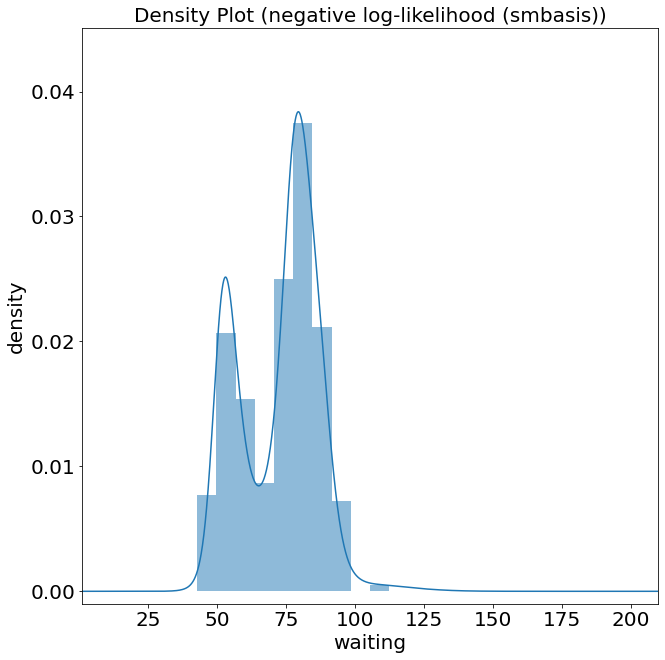

3.0240405758542157
**************************************************
log penalty = -11.0
start time = 18:54:36
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3449260692743947, Relative Error = 0.5601686306274758
Iter = 3, GradNorm = 0.18905680483080486, Relative Error = 0.30703301636684843
Iter = 4, GradNorm = 0.12618180976492452, Relative Error = 0.20492243956743322
Iter = 5, GradNorm = 0.11483852611454007, Relative Error = 0.1865006610030532
Iter = 6, GradNorm = 0.08132576929645194, Relative Error = 0.132075099215765
Iter = 7, GradNorm = 0.08474816011658809, Relative Error = 0.13763314817164896
Iter = 8, GradNorm = 0.09998495901725774, Relative Error = 0.1623780936415272
Iter = 9, GradNorm = 0.0649568811983637, Relative Error = 0.10549161235410329
Iter = 10, GradNorm = 0.06276993749160338, Relative Error = 0.10193996065073277
Iter = 11, GradNorm = 0.05255724426719425, Relative Error = 0.08535428943553465
Iter = 12, GradNorm = 0.08828559412113796

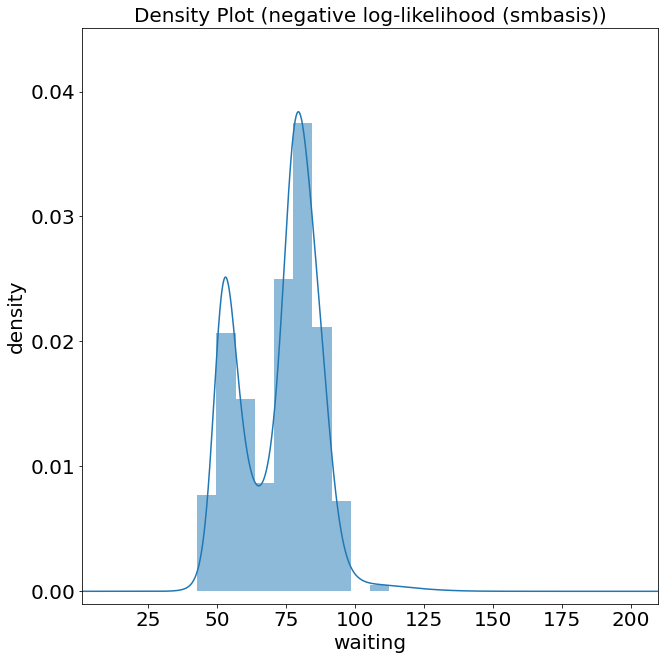

3.02314441964944
**************************************************
log penalty = -10.0
start time = 18:58:30
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.34483574441265674, Relative Error = 0.5600219407753061
Iter = 3, GradNorm = 0.18895141956284242, Relative Error = 0.306861868035361
Iter = 4, GradNorm = 0.12609008963483306, Relative Error = 0.20477348376428853
Iter = 5, GradNorm = 0.11474815850888605, Relative Error = 0.18635390173368635
Iter = 6, GradNorm = 0.08123962227610791, Relative Error = 0.13193519428332462
Iter = 7, GradNorm = 0.08468104112941811, Relative Error = 0.13752414524469941
Iter = 8, GradNorm = 0.09990780051579853, Relative Error = 0.1622527862903183
Iter = 9, GradNorm = 0.06488131493861037, Relative Error = 0.10536889084355841
Iter = 10, GradNorm = 0.06270309928854491, Relative Error = 0.10183141372425769
Iter = 11, GradNorm = 0.05246875541095681, Relative Error = 0.08521058130257562
Iter = 12, GradNorm = 0.0882119543440405

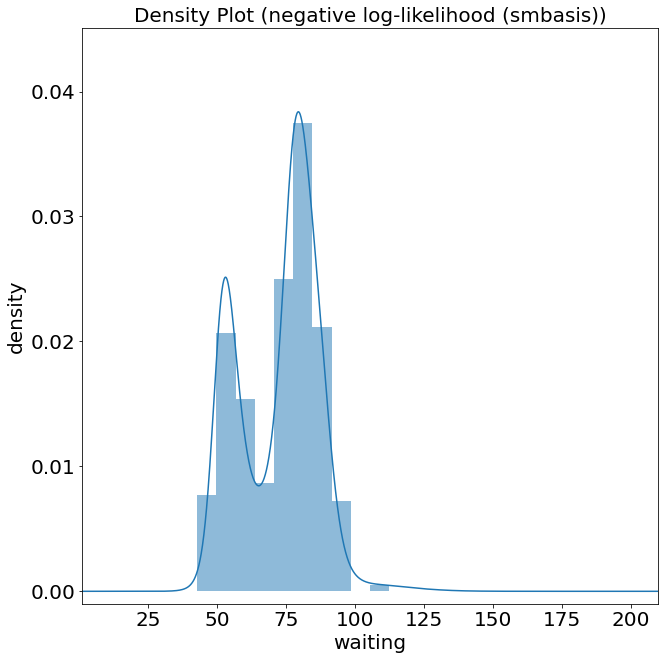

3.0207121825814913
**************************************************
log penalty = -9.5
start time = 19:02:26
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3447430509520425, Relative Error = 0.5598714042588588
Iter = 3, GradNorm = 0.18884330705068988, Relative Error = 0.30668629059056657
Iter = 4, GradNorm = 0.12599603092989886, Relative Error = 0.20462073005665365
Iter = 5, GradNorm = 0.11465551587113462, Relative Error = 0.18620344775484937
Iter = 6, GradNorm = 0.08115134727023073, Relative Error = 0.1317918334487409
Iter = 7, GradNorm = 0.084612322505864, Relative Error = 0.13741254446794196
Iter = 8, GradNorm = 0.09982880595429985, Relative Error = 0.162124497131326
Iter = 9, GradNorm = 0.06480403904880662, Relative Error = 0.10524339285071911
Iter = 10, GradNorm = 0.06263479349885721, Relative Error = 0.10172048340010512
Iter = 11, GradNorm = 0.05237826754404302, Relative Error = 0.08506362672589161
Iter = 12, GradNorm = 0.08813664914912792,

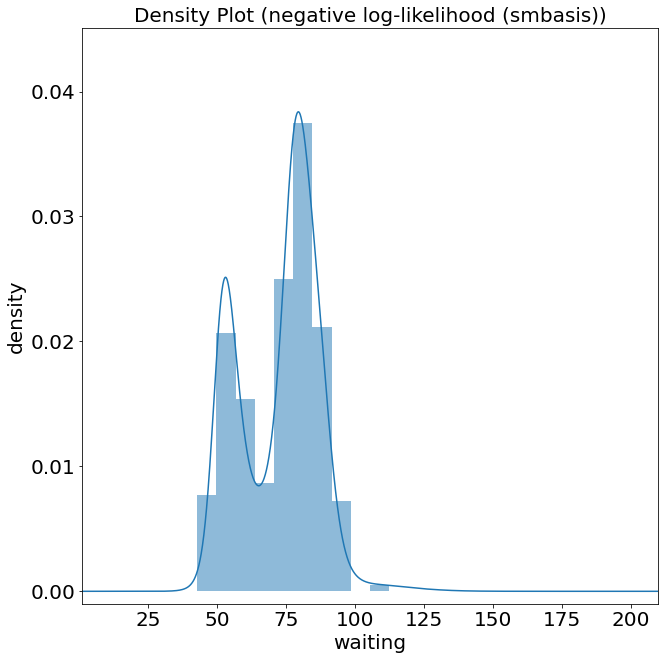

3.018221785092169
**************************************************
log penalty = -9.0
start time = 19:06:12
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.34459023303661385, Relative Error = 0.55962322411231
Iter = 3, GradNorm = 0.18866514897793915, Relative Error = 0.30639695738980866
Iter = 4, GradNorm = 0.12584110950472022, Relative Error = 0.20436913375725033
Iter = 5, GradNorm = 0.11450299097476073, Relative Error = 0.18595574347863128
Iter = 6, GradNorm = 0.08100610328273833, Relative Error = 0.13155595355206728
Iter = 7, GradNorm = 0.08449938444812408, Relative Error = 0.13722913021548205
Iter = 8, GradNorm = 0.09969898574375095, Relative Error = 0.1619136658371767
Iter = 9, GradNorm = 0.06467723909867353, Relative Error = 0.10503746653561308
Iter = 10, GradNorm = 0.06252281036730639, Relative Error = 0.10153861997184595
Iter = 11, GradNorm = 0.0522297943939923, Relative Error = 0.08482250258782974
Iter = 12, GradNorm = 0.08801308252877944

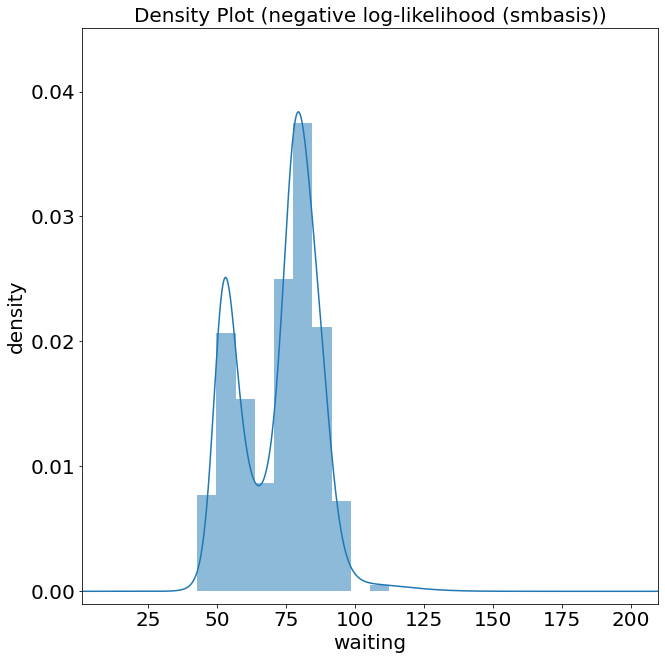

3.01412840787038
**************************************************
log penalty = -8.5
start time = 19:09:57
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.34433830002614907, Relative Error = 0.5592140785531508
Iter = 3, GradNorm = 0.18837165886286078, Relative Error = 0.30592032204527814
Iter = 4, GradNorm = 0.1255861088379298, Relative Error = 0.20395500624689553
Iter = 5, GradNorm = 0.11425210897096677, Relative Error = 0.18554830478079676
Iter = 6, GradNorm = 0.08076744194324015, Relative Error = 0.1311683615210803
Iter = 7, GradNorm = 0.08431415584480226, Relative Error = 0.13692831429485855
Iter = 8, GradNorm = 0.09948608536380105, Relative Error = 0.16156791025382086
Iter = 9, GradNorm = 0.06446982362817928, Relative Error = 0.10470061858346456
Iter = 10, GradNorm = 0.06233989579002304, Relative Error = 0.10124156208783572
Iter = 11, GradNorm = 0.051986940347616924, Relative Error = 0.08442810149519381
Iter = 12, GradNorm = 0.087810948272445

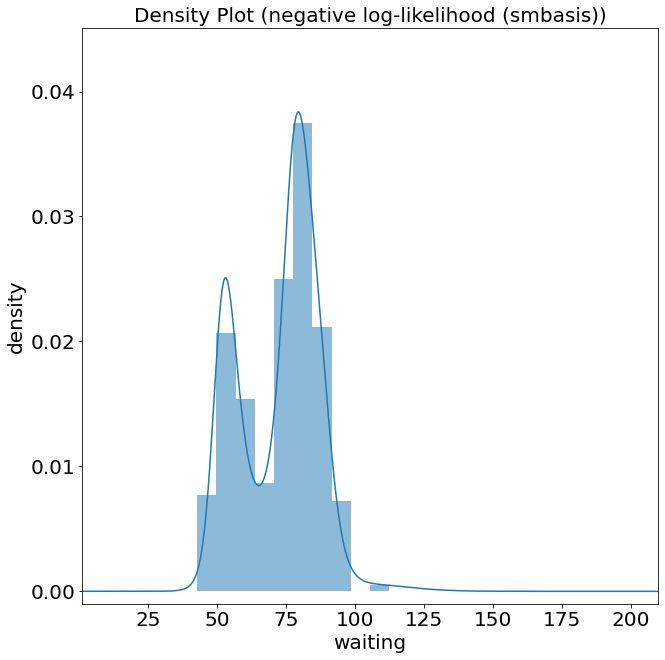

3.007413619689221
**************************************************
log penalty = -8.0
start time = 19:13:40
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3439229903070031, Relative Error = 0.5585396051010579
Iter = 3, GradNorm = 0.1878884360529814, Relative Error = 0.30513555602203285
Iter = 4, GradNorm = 0.1251668289296111, Relative Error = 0.20327408510751457
Iter = 5, GradNorm = 0.11384007203300227, Relative Error = 0.18487914640783568
Iter = 6, GradNorm = 0.08037613869365592, Relative Error = 0.1305328751806573
Iter = 7, GradNorm = 0.08401140062694332, Relative Error = 0.1364366321898784
Iter = 8, GradNorm = 0.09913814388043544, Relative Error = 0.16100284451470345
Iter = 9, GradNorm = 0.06413228976308101, Relative Error = 0.10415245507874528
Iter = 10, GradNorm = 0.0620429396874914, Relative Error = 0.10075929789231824
Iter = 11, GradNorm = 0.05159176259859556, Relative Error = 0.08378632287002516
Iter = 12, GradNorm = 0.08748195716493266, 

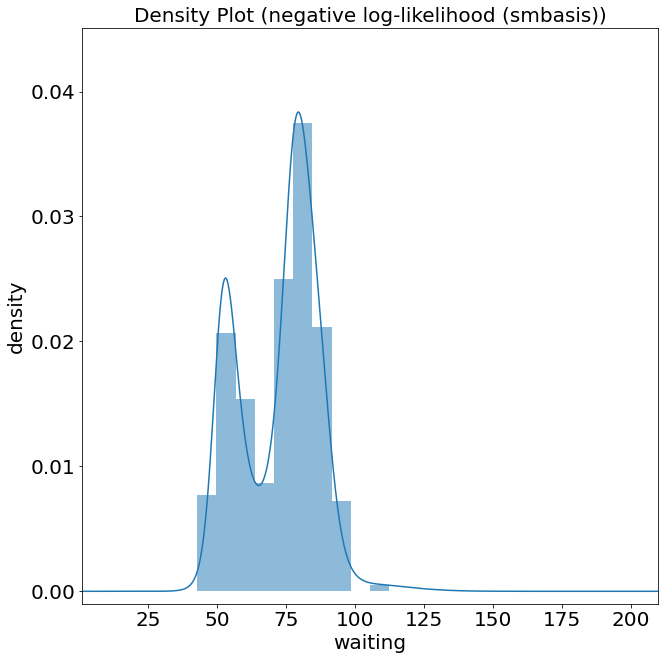

2.9964345424942653
**************************************************
log penalty = -7.5
start time = 19:17:27
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3432384175124525, Relative Error = 0.557427841627526
Iter = 3, GradNorm = 0.18709353353935776, Relative Error = 0.3038446143037812
Iter = 4, GradNorm = 0.124478662097894, Relative Error = 0.20215648482703374
Iter = 5, GradNorm = 0.11316506439891214, Relative Error = 0.1837829169959887
Iter = 6, GradNorm = 0.07973689151143185, Relative Error = 0.12949472164401038
Iter = 7, GradNorm = 0.0835193393754811, Relative Error = 0.1356375123147229
Iter = 8, GradNorm = 0.09857275232709721, Relative Error = 0.16008463438095485
Iter = 9, GradNorm = 0.06358772533088944, Relative Error = 0.10326806871470241
Iter = 10, GradNorm = 0.06156571408245278, Relative Error = 0.0999842714808985
Iter = 11, GradNorm = 0.05095422103440724, Relative Error = 0.08275093930005972
Iter = 12, GradNorm = 0.0869509015616941, Rel

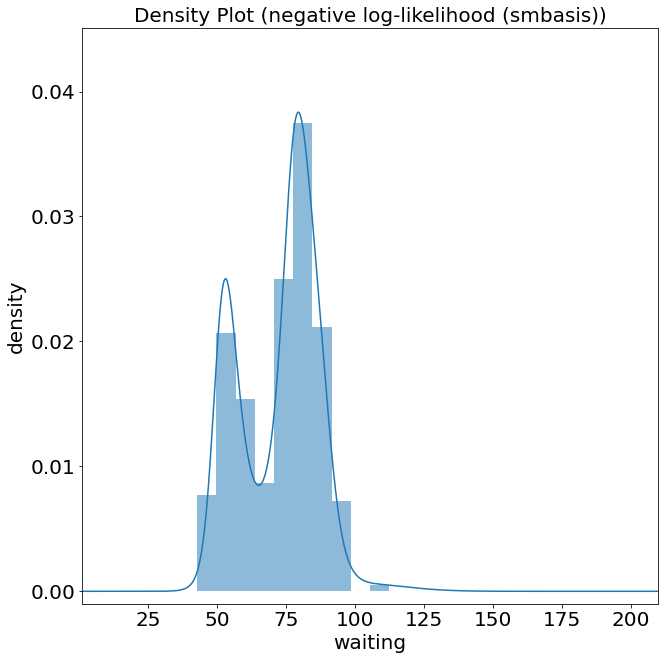

2.978578838328944
**************************************************
log penalty = -7.0
start time = 19:21:18
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.34211017780893416, Relative Error = 0.5555955519108661
Iter = 3, GradNorm = 0.18578785321022206, Relative Error = 0.3017241565385917
Iter = 4, GradNorm = 0.12335250022270036, Relative Error = 0.20032756955594636
Iter = 5, GradNorm = 0.1120638528786404, Relative Error = 0.1819945217301873
Iter = 6, GradNorm = 0.07869885962287004, Relative Error = 0.1278089316925969
Iter = 7, GradNorm = 0.08272706941060108, Relative Error = 0.13435084592198623
Iter = 8, GradNorm = 0.09766268081576146, Relative Error = 0.15860665530749585
Iter = 9, GradNorm = 0.06272177409113826, Relative Error = 0.101861742074382
Iter = 10, GradNorm = 0.060811716331953196, Relative Error = 0.09875976012899615
Iter = 11, GradNorm = 0.04994027167315386, Relative Error = 0.0811042599800137
end time = 19:24:10


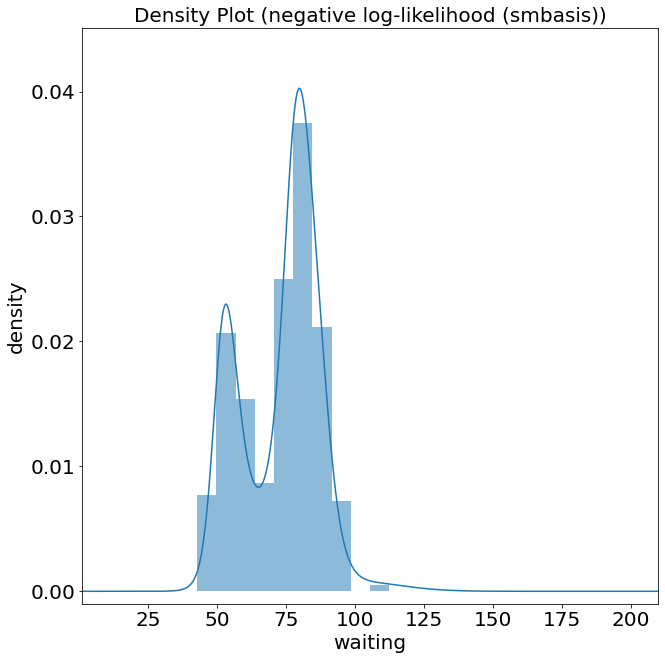

2.779155040174485
**************************************************
log penalty = -6.5
start time = 19:24:13
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3402512065542145, Relative Error = 0.5525765357364064
Iter = 3, GradNorm = 0.1836484810289895, Relative Error = 0.29824976219175503
Iter = 4, GradNorm = 0.12151861966847465, Relative Error = 0.1973493013115193
Iter = 5, GradNorm = 0.11027970801165775, Relative Error = 0.17909702549546908
Iter = 6, GradNorm = 0.07703006559598188, Relative Error = 0.12509876812969847
Iter = 7, GradNorm = 0.08147118915940553, Relative Error = 0.13231126473862068
Iter = 8, GradNorm = 0.09622066758422512, Relative Error = 0.15626478947243247
Iter = 9, GradNorm = 0.06137822940538358, Relative Error = 0.09967979163964318
Iter = 10, GradNorm = 0.059654168980511, Relative Error = 0.09687987405338612
Iter = 11, GradNorm = 0.04836579298863534, Relative Error = 0.078547266910414
end time = 19:27:04


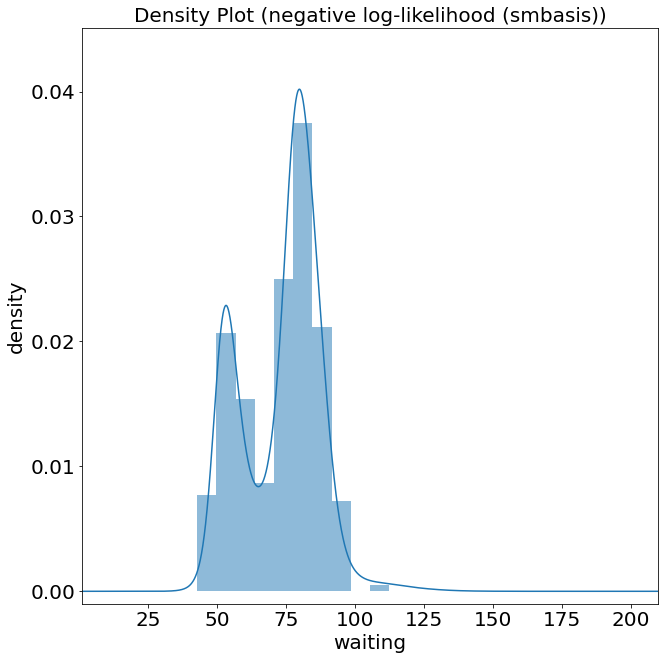

2.7453464280128816
**************************************************
log penalty = -6.0
start time = 19:27:08
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3371895505001298, Relative Error = 0.5476043291331862
Iter = 3, GradNorm = 0.18015763607948165, Relative Error = 0.2925805420043326
Iter = 4, GradNorm = 0.11855681513021507, Relative Error = 0.19253925608683303
Iter = 5, GradNorm = 0.10742217250898946, Relative Error = 0.17445631581276397
Iter = 6, GradNorm = 0.07439183549144823, Relative Error = 0.12081421594132462
Iter = 7, GradNorm = 0.07953169301539167, Relative Error = 0.12916147411425583
Iter = 8, GradNorm = 0.09399488173442916, Relative Error = 0.15265005714972607
Iter = 9, GradNorm = 0.05938070485736099, Relative Error = 0.09643576142451775
Iter = 10, GradNorm = 0.05796253323319594, Relative Error = 0.09413261496077131
Iter = 11, GradNorm = 0.04601760134582705, Relative Error = 0.0747337444945238
end time = 19:29:58


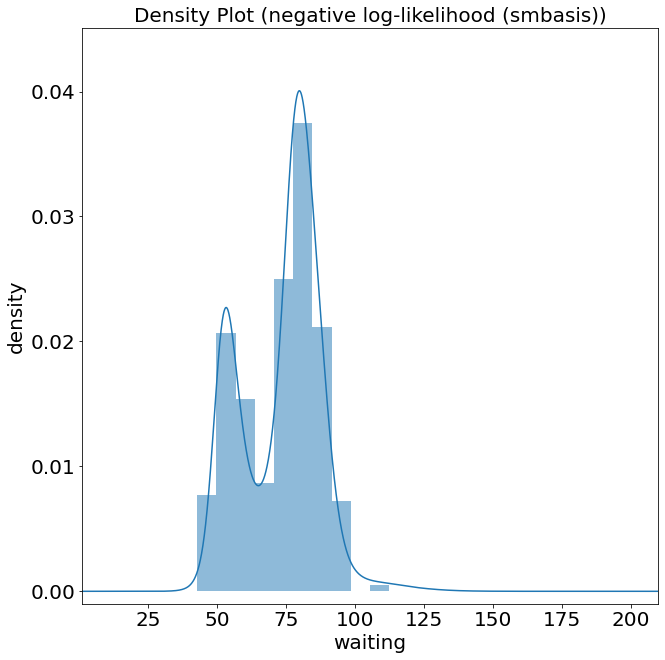

2.6917987695275625


In [10]:
waiting = waiting.reshape(-1, 1)
for log_pen_param in ml_log_pen_param_list: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -5.5
start time = 19:30:58
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.37410902394420453, Relative Error = 0.6075624845899795
Iter = 3, GradNorm = 0.23326687986185385, Relative Error = 0.37883129256608694
Iter = 4, GradNorm = 0.1460443700576353, Relative Error = 0.2371797381338464
Iter = 5, GradNorm = 0.11955856878589788, Relative Error = 0.19416612927363033
Iter = 6, GradNorm = 0.08304431589966504, Relative Error = 0.13486606221666694
Iter = 7, GradNorm = 0.07706843202200996, Relative Error = 0.12516107617262323
Iter = 8, GradNorm = 0.09283378725733865, Relative Error = 0.15076441045265515
Iter = 9, GradNorm = 0.060061850057331195, Relative Error = 0.09754195839805603
Iter = 10, GradNorm = 0.05606146224301547, Relative Error = 0.09104522775476732
Iter = 11, GradNorm = 0.04886445987855225, Relative Error = 0.0793571145089201
end time = 19:33:48


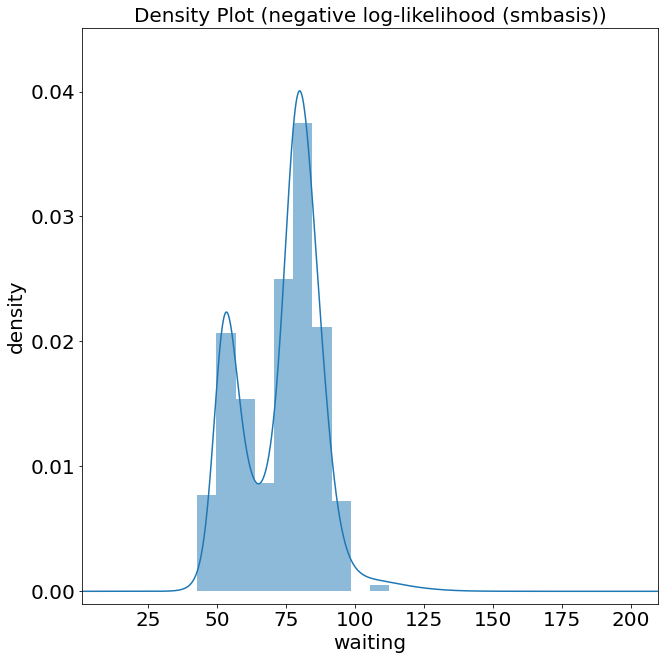

2.5368621866125007
**************************************************
log penalty = -5.0
start time = 19:33:51
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.36701449184073776, Relative Error = 0.596040785630832
Iter = 3, GradNorm = 0.224299250084183, Relative Error = 0.36426763577116994
Iter = 4, GradNorm = 0.1381194284716407, Relative Error = 0.2243094332439664
Iter = 5, GradNorm = 0.11216643593559404, Relative Error = 0.18216111920036454
Iter = 6, GradNorm = 0.07631307645492462, Relative Error = 0.12393435969236082
Iter = 7, GradNorm = 0.07221800441684814, Relative Error = 0.11728385948309623
Iter = 8, GradNorm = 0.0874006635934983, Relative Error = 0.1419408806765336
Iter = 9, GradNorm = 0.05552063440991122, Relative Error = 0.09016690972182612
Iter = 10, GradNorm = 0.052296832704028025, Relative Error = 0.08493137449307972
Iter = 11, GradNorm = 0.0442213278490737, Relative Error = 0.07181655105934656
end time = 19:36:35


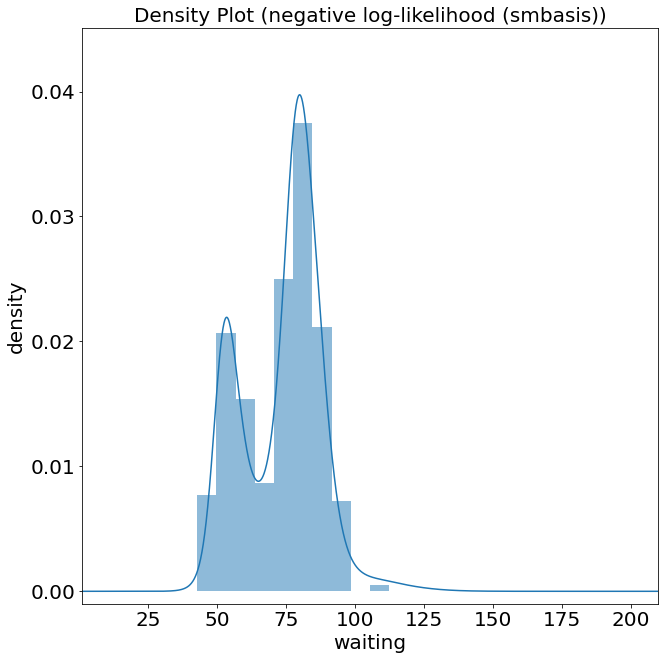

2.431177465744766
**************************************************
log penalty = -4.5
start time = 19:36:38
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3553477694095839, Relative Error = 0.5770937343339602
Iter = 3, GradNorm = 0.20996020256288608, Relative Error = 0.3409806611699044
Iter = 4, GradNorm = 0.12595215612250407, Relative Error = 0.2045494762635464
Iter = 5, GradNorm = 0.10117919680080421, Relative Error = 0.16431756590368504
Iter = 6, GradNorm = 0.06674075292188927, Relative Error = 0.10838866499696242
Iter = 7, GradNorm = 0.06596272598839445, Relative Error = 0.10712512964620186
Iter = 8, GradNorm = 0.08026484805544946, Relative Error = 0.1303521363790442
Iter = 9, GradNorm = 0.05044011405984745, Relative Error = 0.08191601661491442
Iter = 10, GradNorm = 0.04824366668772602, Relative Error = 0.07834893071945029
end time = 19:39:07


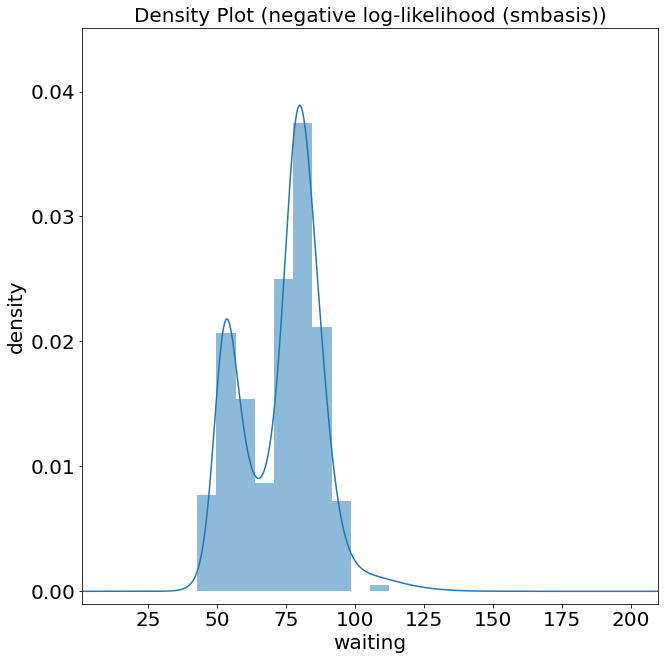

2.2782659730271617
**************************************************
log penalty = -4.0
start time = 19:39:10
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3362039039365746, Relative Error = 0.5460036142699958
Iter = 3, GradNorm = 0.1875376295139743, Relative Error = 0.3045658373603377
Iter = 4, GradNorm = 0.10825306453639578, Relative Error = 0.17580570540854204
Iter = 5, GradNorm = 0.07514660355754633, Relative Error = 0.12203997830517534
Iter = 6, GradNorm = 0.07790254605292403, Relative Error = 0.12651569838331092
Iter = 7, GradNorm = 0.0689719967521613, Relative Error = 0.11201226121753452
Iter = 8, GradNorm = 0.06558025250305068, Relative Error = 0.10650398306546631
Iter = 9, GradNorm = 0.03651012409277548, Relative Error = 0.05929336179231924
end time = 19:41:30


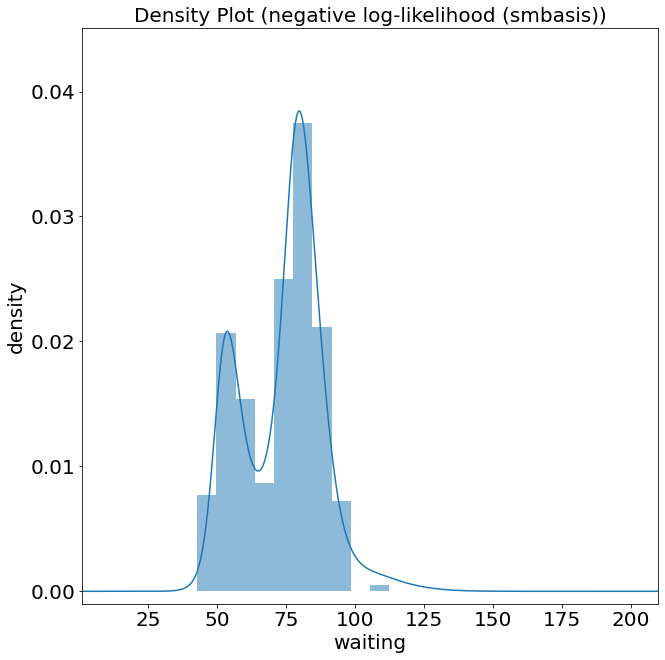

2.0782339455866574


In [12]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.5, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

for log_pen_param in [-5.5, -5., -4.5, -4.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -3.5
start time = 19:43:55
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.48804150296313237, Relative Error = 0.7925917022721471
Iter = 3, GradNorm = 0.3907213962243312, Relative Error = 0.634541395900477
Iter = 4, GradNorm = 0.3158277813502397, Relative Error = 0.5129122775940058
Iter = 5, GradNorm = 0.2386172802802825, Relative Error = 0.3875204777065571
Iter = 6, GradNorm = 0.20927375275856788, Relative Error = 0.33986584938519837
Iter = 7, GradNorm = 0.1601624819947631, Relative Error = 0.26010790777757065
Iter = 8, GradNorm = 0.1264686110474383, Relative Error = 0.20538821207928168
Iter = 9, GradNorm = 0.13029364772618232, Relative Error = 0.2116001680585422
Iter = 10, GradNorm = 0.08899743339553737, Relative Error = 0.14453407508285138
Iter = 11, GradNorm = 0.07135466819019234, Relative Error = 0.11588177968995614
Iter = 12, GradNorm = 0.05791468798526605, Relative Error = 0.094

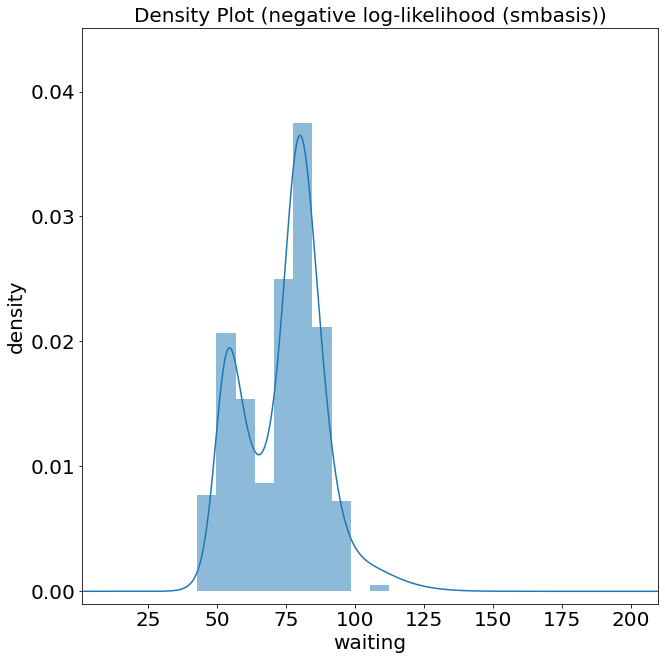

1.749480460388048
**************************************************
log penalty = -3.0
start time = 19:47:20
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.4666976577812687, Relative Error = 0.7579287597088291
Iter = 3, GradNorm = 0.3575068273604376, Relative Error = 0.5806000988668565
Iter = 4, GradNorm = 0.27678210791889896, Relative Error = 0.4495011197653928
Iter = 5, GradNorm = 0.19853839147195487, Relative Error = 0.32243135206273216
Iter = 6, GradNorm = 0.17127909306845526, Relative Error = 0.2781615643639464
Iter = 7, GradNorm = 0.1251305177720605, Relative Error = 0.20321511487240185
Iter = 8, GradNorm = 0.09583579070941946, Relative Error = 0.15563973972663153
Iter = 9, GradNorm = 0.10127048484024664, Relative Error = 0.16446581998072451
Iter = 10, GradNorm = 0.0675926580372434, Relative Error = 0.1097721803772187
Iter = 11, GradNorm = 0.05323342733428144, Relative Error = 0.08645242778019654
Iter = 12, GradNorm = 0.04243637964272177, Re

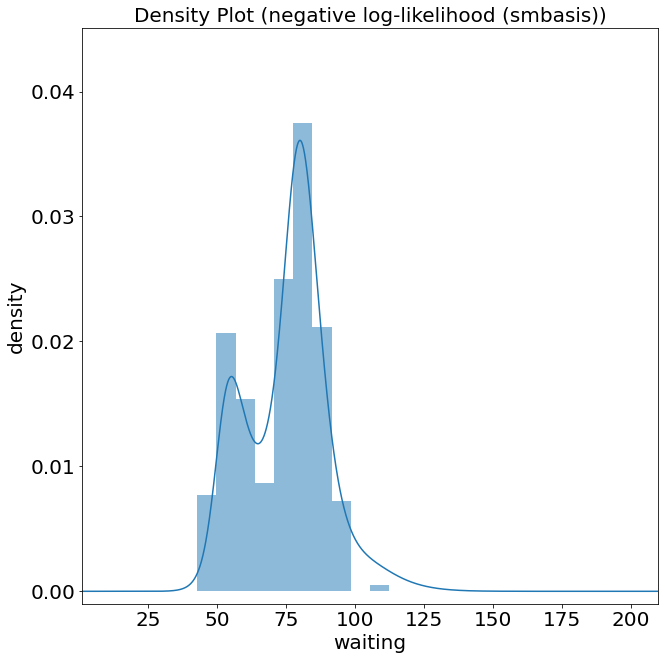

1.4634345391041963
**************************************************
log penalty = -2.5
start time = 19:49:58
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.43164440265994514, Relative Error = 0.7010013898476465
Iter = 3, GradNorm = 0.30658384140559863, Relative Error = 0.49789988612331976
Iter = 4, GradNorm = 0.2209109687990552, Relative Error = 0.3587649815598965
Iter = 5, GradNorm = 0.14535735095388833, Relative Error = 0.23606400179251844
Iter = 6, GradNorm = 0.12458156822425964, Relative Error = 0.2023236069700793
Iter = 7, GradNorm = 0.08502986948215367, Relative Error = 0.13809065128202785
Iter = 8, GradNorm = 0.06511180237979426, Relative Error = 0.10574320825765361
Iter = 9, GradNorm = 0.07195023722686768, Relative Error = 0.11684899881729077
Iter = 10, GradNorm = 0.04448290059184459, Relative Error = 0.0722413517867479
end time = 19:52:07


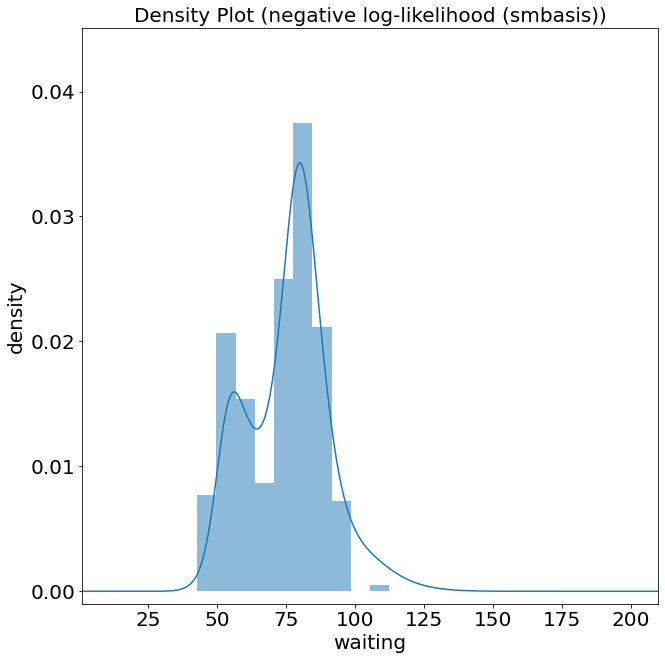

1.1954874862283005
**************************************************
log penalty = -2.0
start time = 19:52:10
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.3743364298516624, Relative Error = 0.6079317975156312
Iter = 3, GradNorm = 0.23313434392876228, Relative Error = 0.3786160508700765
Iter = 4, GradNorm = 0.149654292557191, Relative Error = 0.2430423432639874
Iter = 5, GradNorm = 0.08640596564803994, Relative Error = 0.1403254661409854
Iter = 6, GradNorm = 0.07879923858384177, Relative Error = 0.12797194965534364
Iter = 7, GradNorm = 0.049687341913255696, Relative Error = 0.08069349567465069
end time = 19:53:39


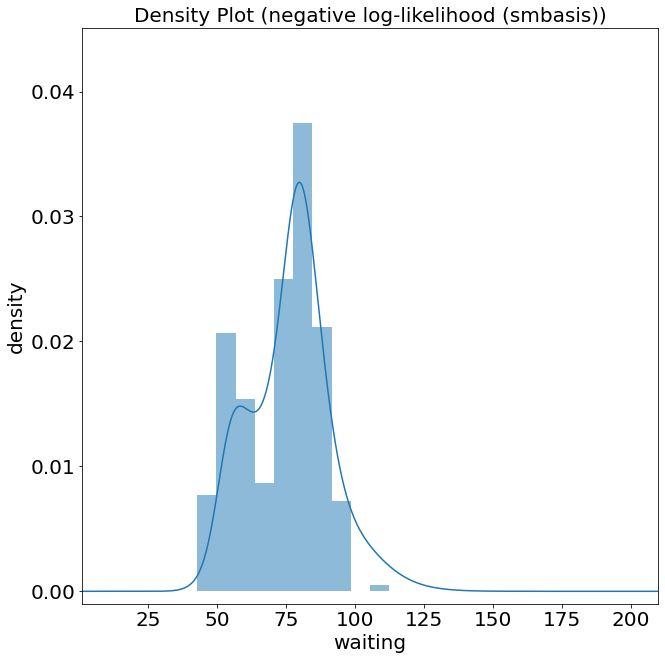

0.8990163749641894
**************************************************
log penalty = -1.5
start time = 19:53:42
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.28204122370833573, Relative Error = 0.45804205636748113
Iter = 3, GradNorm = 0.14102844202473666, Relative Error = 0.22903374457810974
Iter = 4, GradNorm = 0.07848645730725791, Relative Error = 0.1274639849782797
Iter = 5, GradNorm = 0.0424012105115009, Relative Error = 0.06886063462567626
end time = 19:54:47


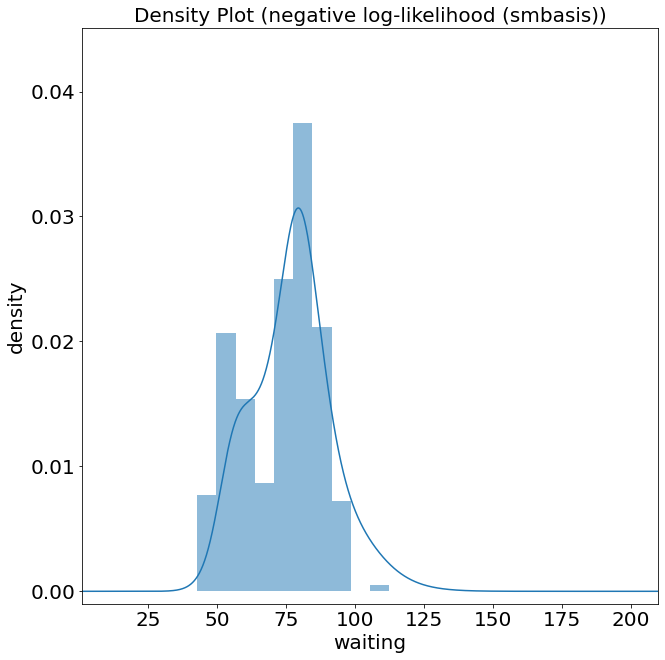

0.6445669499271034


In [13]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.2, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

for log_pen_param in [-3.5, -3., -2.5, -2., -1.5]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -1.0
start time = 19:54:50
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.37167345094035875, Relative Error = 0.6036070526412503
Iter = 3, GradNorm = 0.22839106055233185, Relative Error = 0.3709128391086617
Iter = 4, GradNorm = 0.14389523588476882, Relative Error = 0.23368949006653778
Iter = 5, GradNorm = 0.08514838589564996, Relative Error = 0.13828312492484285
Iter = 6, GradNorm = 0.07653692468206444, Relative Error = 0.12429789485550195
Iter = 7, GradNorm = 0.0499644111670859, Relative Error = 0.08114346312661377
end time = 19:56:22


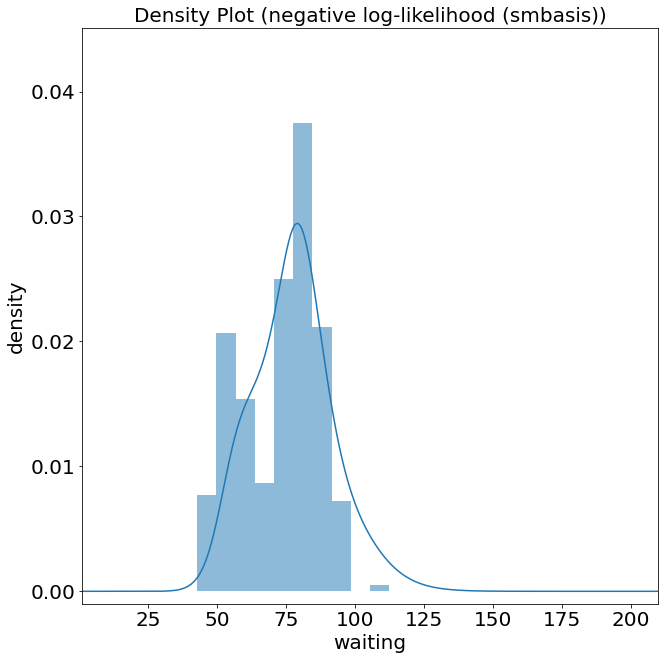

0.44081162278310204
**************************************************
log penalty = -0.5
start time = 19:56:25
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.25037466800388797, Relative Error = 0.4066147717236585
Iter = 3, GradNorm = 0.11712808953092736, Relative Error = 0.19021896970146637
Iter = 4, GradNorm = 0.06131492711334369, Relative Error = 0.09957698712178761
Iter = 5, GradNorm = 0.03354673090432285, Relative Error = 0.0544807365596763
end time = 19:57:33


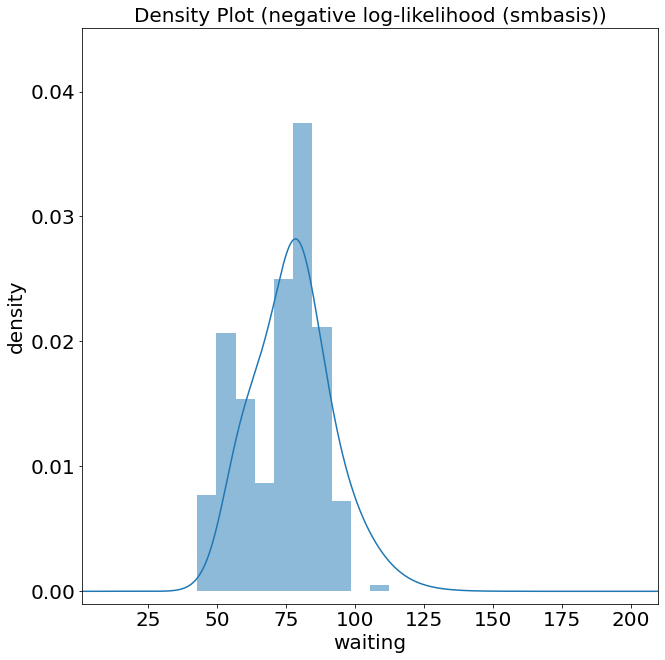

0.2925964303923205
**************************************************
log penalty = 0.0
start time = 19:57:36
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.12837766574141446, Relative Error = 0.20848856502148524
Iter = 3, GradNorm = 0.06763367376323605, Relative Error = 0.10983879095006356
Iter = 4, GradNorm = 0.03672939439713026, Relative Error = 0.05964946229346743
end time = 19:58:31


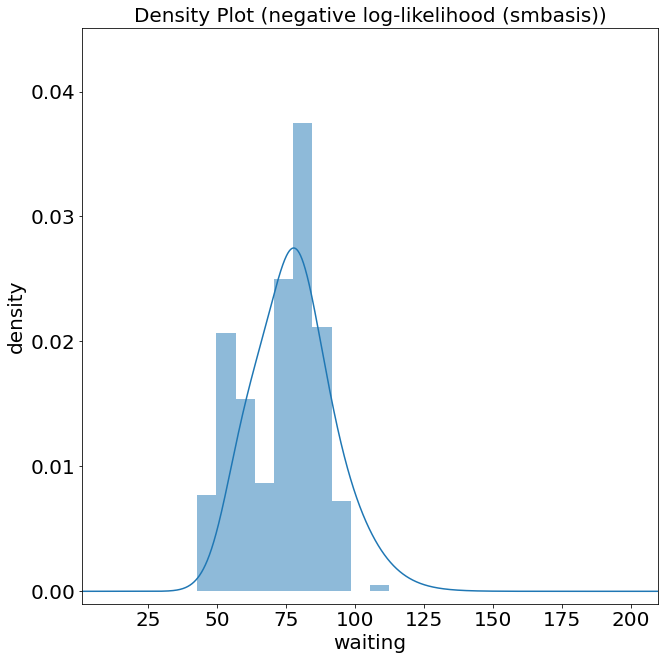

0.19213202649325561


In [14]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.1, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

for log_pen_param in [-1., -0.5, 0.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = 0.5
start time = 19:58:34
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.18026810842359098, Relative Error = 0.29275995187570625
Iter = 3, GradNorm = 0.077968188000247, Relative Error = 0.126622302560319
Iter = 4, GradNorm = 0.03864070464815058, Relative Error = 0.06275347831716376
end time = 19:59:29


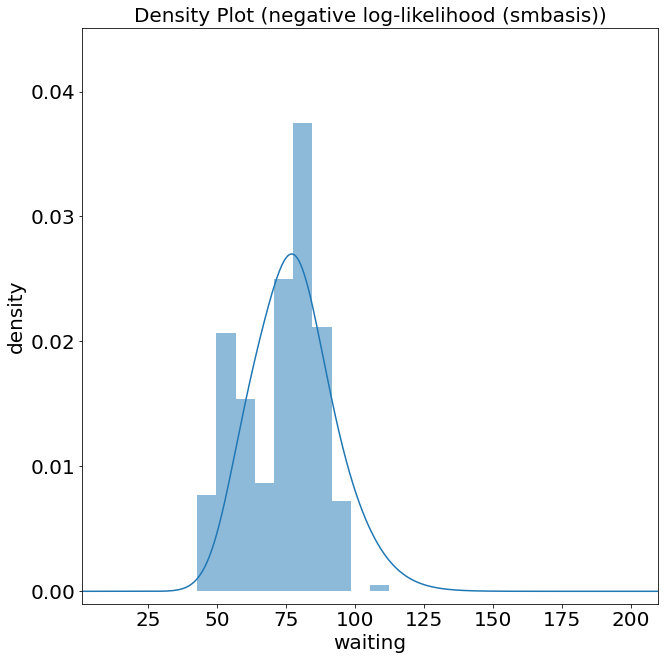

0.11965342134226414
**************************************************
log penalty = 1.0
start time = 19:59:32
Iter = 1, GradNorm = 0.6157539898084331, Relative Error = 1.0
Iter = 2, GradNorm = 0.22988138570124975, Relative Error = 0.3733331647152916
Iter = 3, GradNorm = 0.15884895334564444, Relative Error = 0.2579747041429059
Iter = 4, GradNorm = 0.1115222901381188, Relative Error = 0.1811150101890764
Iter = 5, GradNorm = 0.07273541795818363, Relative Error = 0.11812415211602982
Iter = 6, GradNorm = 0.05499821098595575, Relative Error = 0.08931848091323975
Iter = 7, GradNorm = 0.03364655867570872, Relative Error = 0.05464285937664242
end time = 20:01:08


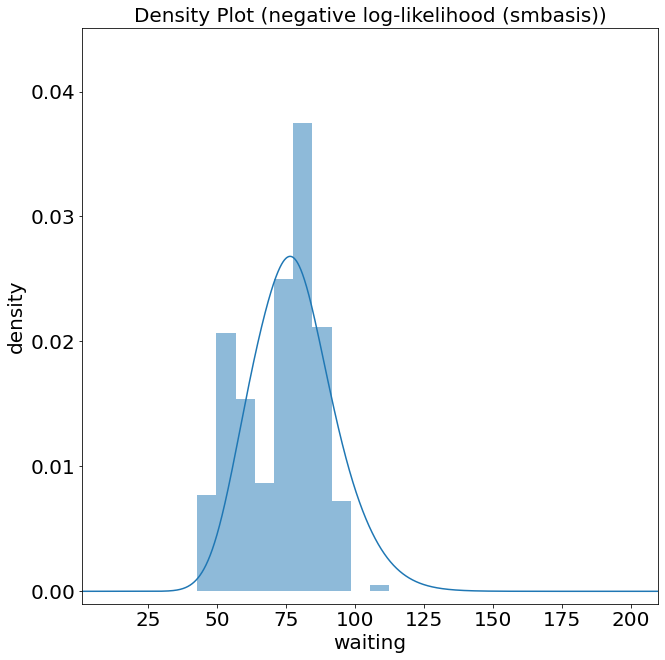

0.07652717819147276


In [15]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.05, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

for log_pen_param in [0.5, 1.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    